# 📊 Exploración de Fuentes y Análisis de Casuística de Fallos (Capa Bronze)

## 1. Introducción y Objetivos
Este Notebook está destinado al **Análisis Exploratorio de Datos (EDA)** del parque eólico Kelmarsh. El objetivo principal es auditar la calidad de los datos en la capa **Bronze** antes de consolidar las transformaciones de producción hacia la capa **Silver**.

Específicamente nos centraremos en:
1. **Inspección Estructural:** Documentar el esquema y consistencia de los logs de estado (`Status`).
2. **Análisis de Casuística de Fallos:** Clasificar y limpiar los más de 38000 eventos para determinar cuáles representan paradas críticas reales y cuáles son alertas operativas o paradas programadas.
3. **Optimización del Target (PdM):** Evaluar la ventana de degradación temporal óptima para el etiquetado del modelo predictivo de IA.

---

## 2. Inicialización del Entorno Spark
Configuramos una sesión local optimizada explotando la paralelización del hardware disponible.

In [9]:
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# ==============================================================================
# 1. CONFIGURACIÓN E INICIALIZACIÓN DEL ENTORNO SPARK LOCAL
# ==============================================================================
# Inicializar Spark optimizado para el hardware local (6 cores en paralelo)
spark = SparkSession.builder \
    .appName("Kelmarsh-EDA-Notebook") \
    .master("local[6]") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

# ==============================================================================
# 2. INGESTA EXCLUSIVA DE RUTAS INTERESADAS (VENTANA ESTRICTA 2021-2024)
# ==============================================================================
# Definir rutas base desde la carpeta de ejecución de notebooks
base_dir = os.path.dirname(os.getcwd())
bronze_dir = os.path.join(base_dir, "data", "bronze")

# Mapear explícitamente solo los directorios de los años requeridos
# De esta forma, ignoramos por completo cualquier carpeta del 2017 al 2020
target_years = ["2018", "2019", "2020", "2021"]
selected_paths = []

for year in target_years:
    # Construimos la ruta exacta hacia los archivos de la Turbina 1 de cada año
    year_pattern = os.path.join(bronze_dir, f"Kelmarsh_SCADA_{year}_*", f"Status_Kelmarsh_1_*.csv")
    selected_paths.append(year_pattern)

# Cargar ÚNICAMENTE los archivos que cumplen con la selección estricta
status_df = spark.read \
    .option("header", "True") \
    .option("inferSchema", "True") \
    .option("comment", "#") \
    .csv(selected_paths)

# ==============================================================================
# 3. INSPECCIÓN DE ESQUEMA Y MUESTRA DE DATOS
# ==============================================================================
print("📋 ESTRUCTURA DE COLUMNAS DETECTADA (SCHEMA):")
status_df.printSchema()

print("VISTA PREVIA DE LAS PRIMERAS 5 FILAS (ESTRICTO 2021-2024):")
status_df.show(5, truncate=False)

# ==============================================================================
# 4. AUDITORÍA DE VOLUMETRÍA EN BRUTO DE LA VENTANA SELECCIONADA
# ==============================================================================
# Calcular las métricas de volumen reales cargadas en memoria
total_records = status_df.count()

print(f"🎯 Total de registros leídos para el entrenamiento (2021-2024): {total_records}")

📋 ESTRUCTURA DE COLUMNAS DETECTADA (SCHEMA):
root
 |-- Timestamp start: string (nullable = true)
 |-- Timestamp end: string (nullable = true)
 |-- Duration: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Code: string (nullable = true)
 |-- Message: string (nullable = true)
 |-- Comment: string (nullable = true)
 |-- Service contract category: string (nullable = true)
 |-- IEC category: string (nullable = true)

VISTA PREVIA DE LAS PRIMERAS 5 FILAS (ESTRICTO 2021-2024):
+-------------------+-------------------+--------+-------------+------+------------------------------+-------+-----------------------------------+----------------+
|Timestamp start    |Timestamp end      |Duration|Status       |Code  |Message                       |Comment|Service contract category          |IEC category    |
+-------------------+-------------------+--------+-------------+------+------------------------------+-------+-----------------------------------+----------------+
|2018-01-03 0

---

## 3. Introducción al Análisis de Códigos y Mensajes del SCADA

Antes de agrupar y filtrar a ciegas, necesitamos entender qué está registrando realmente el sistema de control de la turbina. El objetivo de esta sección es extraer la lista completa de códigos únicos presentes en la capa Bronze.

Analizaremos la combinación de:
* El mensaje de error (`Message`).
* La categoría contractual (`Service contract category`).
* La norma internacional de energía eólica (`IEC category`).

Esto nos permitirá concluir con datos reales qué eventos son averías críticas y cuáles son simples paradas operacionales o caídas de comunicación.

In [10]:
# ==============================================================================
# EXPLORACIÓN INICIAL: VOLUMETRÍA GENERAL DE EVENTOS EN BRUTO
# ==============================================================================
# Agrupar de forma estricta por código y mensaje para consolidar el catálogo único
# Se extrae el primer valor detectado de las categorías para evitar duplicados por strings
raw_catalog_df = status_df.groupBy("Code", "Message") \
    .agg(
        F.first("Status").alias("Status"),
        F.first("Service contract category").alias("Service contract category"),
        F.first("IEC category").alias("IEC category"),
        F.count("*").alias("Occurrence_Count")
    ) \
    .orderBy(F.desc("Occurrence_Count"))

# Calcular dinámicamente el número total de códigos únicos reales en la ventana
total_raw_codes = raw_catalog_df.count()

print(f"📊 EL CATÁLOGO EN BRUTO TIENE UN TOTAL DE: {total_raw_codes} CÓDIGOS ÚNICOS\n")
print("🎯 MOSTRANDO LOS EVENTOS MÁS FRECUENTES EN EL PARQUE:")

# Mostrar el Top 40 de casuísticas en la consola de Spark sin truncar textos
raw_catalog_df.show(truncate=False)

# Sumar el total de frecuencias acumuladas en el catálogo consolidado
total_catalog_sum = raw_catalog_df.agg(F.sum("Occurrence_Count")).collect()[0][0]

# Validar mediante un condicional booleano si el cuadre es perfecto al 100%
if total_catalog_sum == total_records:
    print("\n✅ ¡VERIFICACIÓN EXITOSA! La suma total de 'Occurrence_Count' cuadra con el numero de eventos inicial. Cero pérdidas de información en Spark.\n")
else:
    print("\n⚠️ ¡ATENCIÓN! Existe una discrepancia entre la carga inicial y la agrupación. Revisar nulos en claves.\n")

📊 EL CATÁLOGO EN BRUTO TIENE UN TOTAL DE: 97 CÓDIGOS ÚNICOS

🎯 MOSTRANDO LOS EVENTOS MÁS FRECUENTES EN EL PARQUE:
+------+-----------------------------+-------------+-----------------------------------+----------------------------------+----------------+
|Code  |Message                      |Status       |Service contract category          |IEC category                      |Occurrence_Count|
+------+-----------------------------+-------------+-----------------------------------+----------------------------------+----------------+
|100130|Automatic start-up           |Informational|NULL                               |Full Performance                  |4529            |
|0     |System OK                    |Informational|System OK (32)                     |Full Performance                  |4397            |
|100180|Run-up                       |Informational|NULL                               |Technical Standby                 |4392            |
|100190|Mains connection             |In

Para evitar pérdidas de información, nuestro análisis no se limita a la frecuencia. Un evento crítico con baja frecuencia (incluso Occurrence_Count = 1) puede ser el precursor de una avería grave o un fallo sistémico.

In [11]:
# Obtener los Status únicos presentes en el dataset
unique_statuses = status_df.select("Status").distinct().rdd.flatMap(lambda x: x).collect()

print("📋 LISTADO DE STATUS ÚNICOS ENCONTRADOS:")
print(unique_statuses)

📋 LISTADO DE STATUS ÚNICOS ENCONTRADOS:
['Stop', 'Informational', 'Communication', 'Warning']


Para filtrar el catalogo de fallos, utilizaremos los estados 'Stop' y 'Warning'. El objetivo es identificar y aislar los códigos específicos que actúan como precursores de fallos. Al separar estos eventos de la operativa normal ('Informational' y 'Communication'), podremos etiquetar con precisión las causas raíz que preceden a una parada definitiva, permitiendo que la IA se entrene exclusivamente sobre el catálogo de señales críticas de anomalía.

---

## 4. Aislamiento de Todos los Eventos Críticos (Stops y Warnings)

En esta sección, filtramos el dataset completo para extraer de forma hermética todos los códigos catalogados como Stop o Warning. Este prefiltro actúa como una red de seguridad técnica que aísla las señales de anomalía y el comportamiento errático de los activos, permitiendo identificar los códigos raíz que preceden a una parada definitiva antes de pasar al entrenamiento de la IA.

In [12]:
# ==============================================================================
# PREFILTRO DE EVENTOS CRÍTICOS Y EXTRACCIÓN DE CÓDIGOS DE FALLO
# ==============================================================================

# Aplicamos prefiltro: Stop y Warning como indicadores de anomalía
critical_events_df = status_df.filter(
    F.col("Status").isin(["Stop", "Warning"])
)

# Consolidamos el catálogo de códigos críticos detectados
critical_codes_catalog = critical_events_df.groupBy("Code", "Message") \
    .agg(
        F.first("Status").alias("Status"),
        F.count("*").alias("Failure_Frequency")
    ) \
    .orderBy(F.desc("Failure_Frequency"))

# Imprimimos resultados del prefiltro
print(f"📊 EL CATÁLOGO DE FALLOS TIENE UN TOTAL DE: {critical_codes_catalog.count()} CÓDIGOS ÚNICOS\n")
print("🎯 CÓDIGOS IDENTIFICADOS EN EL PREFILTRO DE EVENTOS CRÍTICOS:")
critical_codes_catalog.show(truncate=False)




📊 EL CATÁLOGO DE FALLOS TIENE UN TOTAL DE: 59 CÓDIGOS ÚNICOS

🎯 CÓDIGOS IDENTIFICADOS EN EL PREFILTRO DE EVENTOS CRÍTICOS:
+----+---------------------------------+-------+-----------------+
|Code|Message                          |Status |Failure_Frequency|
+----+---------------------------------+-------+-----------------+
|710 |Battery test                     |Stop   |197              |
|6052|High yaw motor current           |Warning|132              |
|6200|Cable autounwind                 |Stop   |66               |
|20  |Manual stop - on site            |Stop   |53               |
|6525|4-20mA anemometer 2              |Warning|37               |
|6635|4-20 mA vane 2                   |Warning|37               |
|5760|Hydraulic oil flushing operation |Stop   |32               |
|2125|Timeout brake closed             |Warning|31               |
|8400|Comm. failure FPM                |Warning|24               |
|5720|Brake accumulator defect         |Warning|22               |
|3000|

La lista de 59 códigos posee el tamaño idóneo para ser exportada a un archivo físico local `.txt`. Este archivo funcionará como nuestra "herramienta de control de calidad", permitiendo auditar el catálogo completo sin truncados y extraer el criterio empírico necesario para diseñar las siguientes capas de filtrado inteligente.

In [13]:
# ==============================================================================
# EXPORTACIÓN A TXT: GUARDADO DEL CATÁLOGO DE FALLOS
# ==============================================================================

# Definimos la ruta del archivo
initial_audit_file_path = "initial_catalog_audit.txt"

# Convertimos a formato Pandas para asegurar que la exportación sea un archivo legible y ordenado
# (Si tu dataset es muy grande, esta opción es segura al tener ya agrupados los 59 códigos)
pd_catalog = critical_codes_catalog.toPandas()

# Exportamos a un archivo de texto plano con formato de tabla
with open(initial_audit_file_path, "w", encoding="utf-8") as f:
    f.write("CATÁLOGO DE CÓDIGOS CRÍTICOS IDENTIFICADOS (PREFILTRO)\n")
    f.write("=" * 60 + "\n\n")
    f.write(pd_catalog.to_string(index=False))

print(f"✅ ¡ÉXITO! Catálogo exportado correctamente en: {initial_audit_file_path}")

✅ ¡ÉXITO! Catálogo exportado correctamente en: initial_catalog_audit.txt


---

## 5. Conclusión de la Auditoría Visual preliminar (59 Eventos)

La inspección lineal de los 59 códigos extraídos en el archivo `initial_catalog_audit.txt` ha sido determinante para detectar de forma quirúrgica el ruido operativo restante. Al tratarse de un volumen tan acotado y manejable, se ha descartado el uso de expresiones regulares complejas para evitar el riesgo de falsos positivos léxicos. En su lugar, la auditoría visual nos ha proporcionado el mapa exacto de los códigos de infraestructura, caídas de red externa (distribuidora) e intervenciones humanas directas. Este análisis empírico justifica la inyección directa de estos IDs específicos en la lista definitiva de exclusión, garantizando una purga 100% segura y permitiendo aislar de forma exacta las 37 averías de funcionamiento puras que entrenarán el modelo de IA.

In [14]:
# ==============================================================================
# FILTRADO CRÍTICO DEFINITIVO: EXCLUSIÓN DE CÓDIGOS DE RUIDO POR ID
# ==============================================================================

# Lista maestra de IDs excluidos tras la inspección visual (Infraestructura, red y humanos)
operational_and_external_ids = [
    # Mantenimiento Programado / Pruebas:
    710, # Battery test: Es un testeo funcional recurrente, no un fallo de desgaste.
    707, # Stop battery test: Acción derivada de la finalización del test anterior.
    5760, # Hydraulic oil flushing operation: Tarea de mantenimiento preventivo (limpieza).
    5700, # Max. operation time hydraulic: Alerta de horas de funcionamiento; es un contador, no un error técnico.

    # Factores Externos / Ambientales:
    3500, # Grid loss: Fallo de la red eléctrica externa, ajeno al estado de la turbina.
    3585, # Maximum grid frequency: Problema de estabilidad de la red (Grid Code).
    3590, # Overvoltage: Pico de tensión externo.
    6540, # Icing (anemometer): Condición climática extrema (hielo).
    6682, # Icing (dev. electr. power): Efecto secundario por hielo.
    6690, # Icing (stop): Parada por seguridad debida a condiciones climáticas.
    64, # Max. wind speed: Parada por seguridad ante viento excesivo.
    68, # Deviation winddirection > 60°: Error de seguimiento por condiciones de viento erráticas/externas.

    # Acciones Operativas (Humanas/Control):
    20, # Manual stop - on site: Acción deliberada de un técnico.
    25, # Manual stop without login: Acción humana (error de procedimiento).
    21, # Manual stop - remote: Parada desde el centro de control.
    8000, # Park master stop: Comando de parada de parque (gestión global).
    210, # Manual brake: Accionamiento manual del freno.
    7325, # Time sync. failed (SNTP error): Problema administrativo/red (no afecta la integridad mecánica).
    7324, # Check time synchronization: Ídem, error de configuración horaria.
]

# ==============================================================================
# APLICACIÓN DEL FILTRADO INTEGRAL EN LA CAPA SILVER
# ==============================================================================
catalogo_fallos_reales_df = status_df.filter(
    # 1. Mantener solo eventos críticos que detienen o avisan de anomalías
    (F.col("Status").isin("Warning", "Stop")) &
    
    # 2. Hachazo directo a los códigos identificados en la auditoría visual
    (~F.col("Code").isin(operational_and_external_ids))
)

# Cacheamos el DataFrame en memoria por eficiencia técnica para los siguientes cálculos
catalogo_fallos_reales_df.cache()

# ==============================================================================
# AUDITORÍA Y VERIFICACIÓN DE VOLUMETRÍA FINAL (SIN DUPLICADOS)
# ==============================================================================

# 1. Agrupamos para obtener los conteos, pero manteniendo los datos necesarios
catalogo_agrupado = catalogo_fallos_reales_df.groupBy(
    "Code", "Message", "Status", "Service contract category", "IEC category"
).count()

# 2. Eliminamos duplicados basándonos ÚNICAMENTE en el código.
# Si un código tiene varias versiones (por mensaje, etc.), nos quedamos con la primera 
# que encuentre o la que tenga mayor conteo si ordenamos antes.
catalogo_final = catalogo_agrupado.orderBy(F.desc("count")).dropDuplicates(["Code"]).orderBy("Code")

# Calcular el nuevo número de códigos únicos
final_failures_count = catalogo_final.count()

print(f"🎯 EL CATÁLOGO DEFINITIVO TIENE EXACTAMENTE: {final_failures_count} CÓDIGOS ÚNICOS.")
print("📋 VISTA GLOBAL DEL CATÁLOGO PURGADO (BASE DEL TARGET):")

# Forzar a show a mostrar el total exacto (37) para evitar cortes (...)
catalogo_final.show(n=final_failures_count + 5, truncate=False)

# ==============================================================================
# EXPORTACIÓN DEL REPORTE DE AUDITORÍA FÍSICO (.TXT)
# ==============================================================================
# Definir la ruta del archivo final en el espacio de trabajo
final_audit_file_path = "failure_catalog_audit.txt"

# Recolectar las 37 filas limpias en local para la escritura secuencial
final_catalog_rows = catalogo_final.collect()

# Abrir el archivo en modo escritura para guardar el catálogo definitivo limpio
with open(final_audit_file_path, "w", encoding="utf-8") as file:
    file.write(f"📋 CATALOGO TOTAL DE AVERIAS DE FUNCIONAMIENTO COMPLETO ({final_failures_count} EVENTOS)\n")
    file.write("=" * 100 + "\n")
    file.write(f"{'CÓDIGO':<8} | {'MENSAJE':<40} | {'STATUS':<8} | {'CATEGORÍA CONTRACTUAL'}\n")
    file.write("-" * 100 + "\n")
    
    for row in final_catalog_rows:
        file.write(f"{str(row['Code']):<8} | {str(row['Message']):<40} | {str(row['Status']):<8} | {str(row['Service contract category'])}\n")

print(f"✅ ¡Archivo '{final_audit_file_path}' generado on éxito!")

# Convertir el DataFrame de Spark a Pandas
catalogo_pd = catalogo_final.toPandas()

# Guardar en formato CSV
csv_file_path = '../data/silver/technical_fault_catalog.csv'
catalogo_pd.to_csv(csv_file_path, index=False, encoding="utf-8")

print(f"✅ ¡El catálogo ha sido guardado correctamente en '{csv_file_path}'!")

26/05/30 14:29:21 WARN CacheManager: Asked to cache already cached data.


🎯 EL CATÁLOGO DEFINITIVO TIENE EXACTAMENTE: 40 CÓDIGOS ÚNICOS.
📋 VISTA GLOBAL DEL CATÁLOGO PURGADO (BASE DEL TARGET):
+----+---------------------------------+-------+-----------------------------------+-------------------------------+-----+
|Code|Message                          |Status |Service contract category          |IEC category                   |count|
+----+---------------------------------+-------+-----------------------------------+-------------------------------+-----+
|100 |Safety chain open                |Stop   |Safety chain (13)                  |Forced outage                  |1    |
|1070|Drive train monitor level 2      |Stop   |Warnings (27)                      |Technical Standby              |1    |
|1860|Oil filter gear choked           |Warning|Warnings (27)                      |NULL                           |3    |
|2000|Brake pads worn                  |Warning|Warnings (27)                      |NULL                           |2    |
|2125|Timeout brake c

✅ Gráfico guardado en: /home/aitor/Documentos/ai-driven-cross-generator-transfer-learning/docs/images/distribucion_averias.png


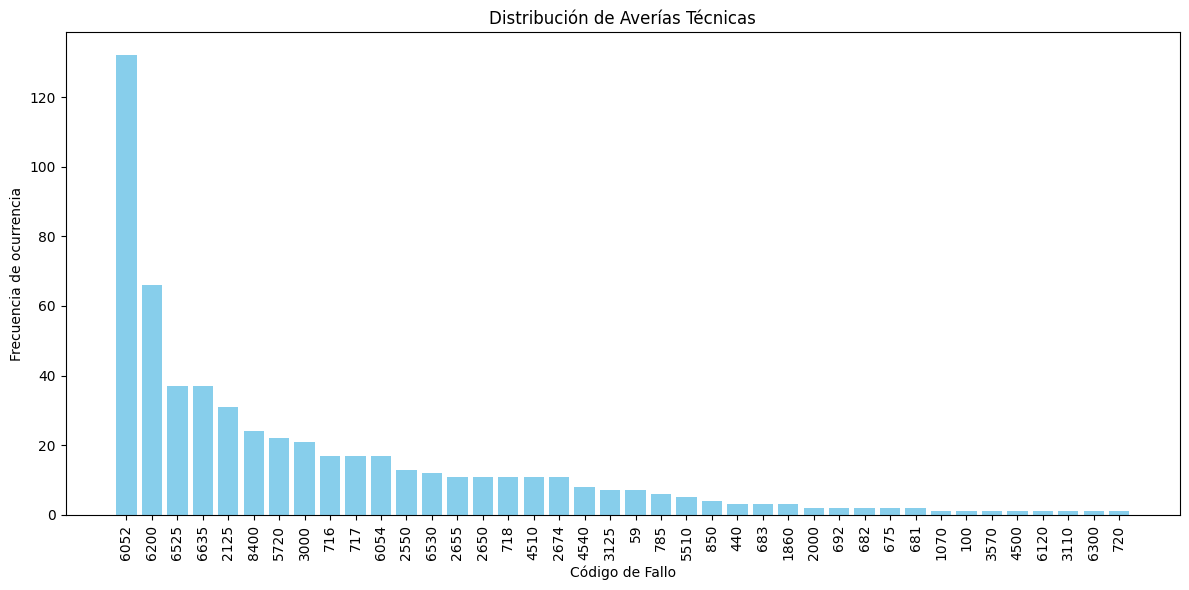

In [15]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definir la ruta de destino
# Usamos base_dir que ya tenías definido en tu script para ser consistentes
images_dir = os.path.join(base_dir, "docs", "images")
os.makedirs(images_dir, exist_ok=True)  # Crea la carpeta si no existe

# 2. Tu lógica de procesamiento...
df_plot = catalogo_final.toPandas()
df_plot = df_plot.sort_values(by='count', ascending=False)
df_plot['Code'] = df_plot['Code'].astype(str)

# 3. Graficar
plt.figure(figsize=(12, 6))
plt.bar(df_plot['Code'], df_plot['count'], color='skyblue')
plt.title('Distribución de Averías Técnicas')
plt.xlabel('Código de Fallo')
plt.ylabel('Frecuencia de ocurrencia')
plt.xticks(rotation=90)
plt.tight_layout()

# 4. Guardar la imagen antes de mostrarla
output_path = os.path.join(images_dir, "distribucion_averias.png")
plt.savefig(output_path, dpi=300) # dpi=300 asegura alta calidad
print(f"✅ Gráfico guardado en: {output_path}")

plt.show()

In [16]:
import os
import shutil
import glob
from pyspark.sql import SparkSession
from pyspark.sql import functions as F


base_dir = os.path.dirname(os.getcwd())
silver_dir = os.path.join(base_dir, "data", "silver")

# Cargar datos y etiquetar
catalog_csv_path = os.path.join(silver_dir, "technical_fault_catalog.csv")
catalog_df = spark.read.option("header", "true").option("inferSchema", "true").csv(catalog_csv_path)
failure_codes = [row.Code for row in catalog_df.select("Code").distinct().collect() if row.Code is not None]

# Aplicar etiquetado
status_df_etiquetado = status_df.withColumn(
    "is_failure_target", 
    F.when(F.col("Code").isin(failure_codes), True).otherwise(False)
)


# Redondear 'Timestamp start' a intervalos de 10 minutos (600 segundos)
status_df_etiquetado = status_df_etiquetado.withColumn(
    "Timestamp start",
    F.to_timestamp(
        F.from_unixtime(
            (F.unix_timestamp(F.col("Timestamp start")) / 600).cast("long") * 600
        )
    )
)

# Asegúrate de convertir la columna a formato de texto con el patrón exacto
# Esto elimina la información de zona horaria (offset)
status_df_etiquetado = status_df_etiquetado.withColumn(
    "Timestamp start", 
    F.date_format(F.col("Timestamp start"), "yyyy-MM-dd HH:mm:ss")
)


status_df_etiquetado.show(5, truncate=False)

# Exportar como carpeta temporal
temp_output_path = os.path.join(silver_dir, "temp_status_labeled")
status_df_etiquetado.coalesce(1).write.mode("overwrite").option("header", "true").csv(temp_output_path)

# 4. EXTRACCIÓN DEL ARCHIVO ÚNICO (La parte que querías)
# Buscamos el archivo real dentro de la carpeta temporal
files = glob.glob(os.path.join(temp_output_path, "part-00000-*.csv"))

if files:
    final_file = os.path.join(silver_dir, "fault_log.csv")
    shutil.move(files[0], final_file) # Movemos el archivo fuera
    shutil.rmtree(temp_output_path)    # Borramos la carpeta temporal
    print(f"✅ Archivo consolidado creado en: {final_file}")

# Guardar catálogo (usando tu lógica anterior)
# Asegúrate de que 'catalogo_final' esté definido en tu sesión
catalogo_pd = catalogo_final.toPandas()
catalogo_pd.to_csv(catalog_csv_path, index=False, encoding="utf-8")

print(f"✅ Pipeline completado.")
# Cuenta cuántos fallos tienes ANTES y DESPUÉS del redondeo

spark.stop()

+-------------------+-------------------+--------+-------------+------+------------------------------+-------+-----------------------------------+----------------+-----------------+
|Timestamp start    |Timestamp end      |Duration|Status       |Code  |Message                       |Comment|Service contract category          |IEC category    |is_failure_target|
+-------------------+-------------------+--------+-------------+------+------------------------------+-------+-----------------------------------+----------------+-----------------+
|2018-01-03 02:20:00|2018-01-03 02:50:55|00:26:59|Stop         |692   |Pitch run-away (hub box v.>=4)|NULL   |Controller error of the WP3100 (16)|Forced outage   |true             |
|2018-01-03 02:20:00|-                  |-       |Informational|100035|Brake program 170             |NULL   |NULL                               |Full Performance|false            |
|2018-01-03 02:30:00|-                  |-       |Informational|100060|Brake program 52   

26/05/30 14:29:23 WARN CSVHeaderChecker: Number of column in CSV header is not equal to number of fields in the schema:
 Header length: 11, schema size: 9
CSV file: file:///home/aitor/Documentos/ai-driven-cross-generator-transfer-learning/data/bronze/Kelmarsh_SCADA_2021_4456/Status_Kelmarsh_1_2021-01-01_-_2022-01-01_228.csv


✅ Archivo consolidado creado en: /home/aitor/Documentos/ai-driven-cross-generator-transfer-learning/data/silver/fault_log.csv
✅ Pipeline completado.
